In [3]:
import pandas as pd
import numpy as np


In [4]:
air=pd.read_csv('airquality.csv')

In [5]:
air.shape

(153, 7)

In [6]:
air.head()

,Unnamed: 0,Ozone,Solar.R,Wind,Temp,Month,Day
0,1,41.0,190.0,7.4,67,5,1
1,2,36.0,118.0,8.0,72,5,2
2,3,12.0,149.0,12.6,74,5,3
3,4,18.0,313.0,11.5,62,5,4
4,5,NaN,NaN,14.3,56,5,5


In [7]:
air.count()

Unnamed: 0    153
Ozone         116
Solar.R       146
Wind          153
Temp          153
Month         153
Day           153
dtype: int64

In [8]:
air.isnull().sum()

Unnamed: 0     0
Ozone         37
Solar.R        7
Wind           0
Temp           0
Month          0
Day            0
dtype: int64

In [9]:
air.describe()

,Unnamed: 0,Ozone,Solar.R,Wind,Temp,Month,Day
count,153.000000,116.000000,146.000000,153.000000,153.000000,153.000000,153.000000
mean,77.000000,42.129310,185.931507,9.957516,77.882353,6.993464,15.803922
std,44.311398,32.987885,90.058422,3.523001,9.465270,1.416522,8.864520
min,1.000000,1.000000,7.000000,1.700000,56.000000,5.000000,1.000000
25%,39.000000,18.000000,115.750000,7.400000,72.000000,6.000000,8.000000
50%,77.000000,31.500000,205.000000,9.700000,79.000000,7.000000,16.000000
75%,115.000000,63.250000,258.750000,11.500000,85.000000,8.000000,23.000000
max,153.000000,168.000000,334.000000,20.700000,97.000000,9.000000,31.000000


In [10]:
air.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 153 entries, 0 to 152
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  153 non-null    int64  
 1   Ozone       116 non-null    float64
 2   Solar.R     146 non-null    float64
 3   Wind        153 non-null    float64
 4   Temp        153 non-null    int64  
 5   Month       153 non-null    int64  
 6   Day         153 non-null    int64  
dtypes: float64(3), int64(4)
memory usage: 8.5 KB


In [ ]:
A=air.dropna()

# Drop Null values

In [12]:
A.shape

(111, 7)

In [13]:
A=air.fillna(0)

In [14]:
A.shape

(153, 7)

In [15]:
A.head()

,Unnamed: 0,Ozone,Solar.R,Wind,Temp,Month,Day
0,1,41.0,190.0,7.4,67,5,1
1,2,36.0,118.0,8.0,72,5,2
2,3,12.0,149.0,12.6,74,5,3
3,4,18.0,313.0,11.5,62,5,4
4,5,0.0,0.0,14.3,56,5,5


In [ ]:
#Error correction
# forward fill -> propagates last non NaN value
A = air.ffill()
A.head(10)

,Unnamed: 0,Ozone,Solar.R,Wind,Temp,Month,Day
0,1,41.0,190.0,7.4,67,5,1
1,2,36.0,118.0,8.0,72,5,2
2,3,12.0,149.0,12.6,74,5,3
3,4,18.0,313.0,11.5,62,5,4
4,5,18.0,313.0,14.3,56,5,5
5,6,28.0,313.0,14.9,66,5,6
6,7,23.0,299.0,8.6,65,5,7
7,8,19.0,99.0,13.8,59,5,8
8,9,8.0,19.0,20.1,61,5,9
9,10,8.0,194.0,8.6,69,5,10


In [ ]:
# Backward fill method.
# It fills missing (NaN) values , the next valid (non-NaN) value propagated backward
A=air.bfill()
A.head(10)

,Unnamed: 0,Ozone,Solar.R,Wind,Temp,Month,Day
0,1,41.0,190.0,7.4,67,5,1
1,2,36.0,118.0,8.0,72,5,2
2,3,12.0,149.0,12.6,74,5,3
3,4,18.0,313.0,11.5,62,5,4
4,5,28.0,299.0,14.3,56,5,5
5,6,28.0,299.0,14.9,66,5,6
6,7,23.0,299.0,8.6,65,5,7
7,8,19.0,99.0,13.8,59,5,8
8,9,8.0,19.0,20.1,61,5,9
9,10,7.0,194.0,8.6,69,5,10


In [ ]:

# Filling Mean value
A=air['Ozone'].replace(np.NaN,air['Ozone'].mean()) # Replace NaN values with mean 
A.head()

0    41.00000
1    36.00000
2    12.00000
3    18.00000
4    42.12931
Name: Ozone, dtype: float64

In [19]:
A=air['Ozone'].replace(np.NaN,air['Ozone'].median())
A.head()

0    41.0
1    36.0
2    12.0
3    18.0
4    31.5
Name: Ozone, dtype: float64

In [20]:
from sklearn.impute import SimpleImputer

In [21]:
imp=SimpleImputer(missing_values=np.nan, strategy='mean')

In [ ]:
A=imp.fit_transform(air)
# fit imp to Air dataset format

In [23]:
A

array([[  1.,  41., 190., ...,  67.,   5.,   1.],
       [  2.,  36., 118., ...,  72.,   5.,   2.],
       [  3.,  12., 149., ...,  74.,   5.,   3.],
       ...,
       [151.,  14., 191., ...,  75.,   9.,  28.],
       [152.,  18., 131., ...,  76.,   9.,  29.],
       [153.,  20., 223., ...,  68.,   9.,  30.]])

In [24]:
imp=SimpleImputer(missing_values=np.nan, strategy='most_frequent')

In [ ]:
A=imp.fit_transform(air)
# fit imp to Air dataset format

In [26]:
A

array([[  1.,  41., 190., ...,  67.,   5.,   1.],
       [  2.,  36., 118., ...,  72.,   5.,   2.],
       [  3.,  12., 149., ...,  74.,   5.,   3.],
       ...,
       [151.,  14., 191., ...,  75.,   9.,  28.],
       [152.,  18., 131., ...,  76.,   9.,  29.],
       [153.,  20., 223., ...,  68.,   9.,  30.]])

In [ ]:
A=pd.DataFrame(A,columns=air.columns) 
# converting into a dataframe

In [28]:
air.head()

,Unnamed: 0,Ozone,Solar.R,Wind,Temp,Month,Day
0,1,41.0,190.0,7.4,67,5,1
1,2,36.0,118.0,8.0,72,5,2
2,3,12.0,149.0,12.6,74,5,3
3,4,18.0,313.0,11.5,62,5,4
4,5,NaN,NaN,14.3,56,5,5


In [29]:
A.head()

,Unnamed: 0,Ozone,Solar.R,Wind,Temp,Month,Day
0,1.0,41.0,190.0,7.4,67.0,5.0,1.0
1,2.0,36.0,118.0,8.0,72.0,5.0,2.0
2,3.0,12.0,149.0,12.6,74.0,5.0,3.0
3,4.0,18.0,313.0,11.5,62.0,5.0,4.0
4,5.0,23.0,238.0,14.3,56.0,5.0,5.0


In [30]:
from sklearn.model_selection import train_test_split

In [31]:
len(A)

153

In [32]:
train,test=train_test_split(A)

In [33]:
len(train)

114

In [34]:
len(test)

39

In [35]:
train.head()

,Unnamed: 0,Ozone,Solar.R,Wind,Temp,Month,Day
140,141.0,13.0,27.0,10.3,76.0,9.0,18.0
112,113.0,21.0,259.0,15.5,77.0,8.0,21.0
8,9.0,8.0,19.0,20.1,61.0,5.0,9.0
10,11.0,7.0,238.0,6.9,74.0,5.0,11.0
60,61.0,23.0,138.0,8.0,83.0,6.0,30.0


In [36]:
train,test=train_test_split(A,test_size=0.20)

In [37]:
len(test)

31

In [38]:
A.describe()

,Unnamed: 0,Ozone,Solar.R,Wind,Temp,Month,Day
count,153.000000,153.000000,153.000000,153.000000,153.000000,153.000000,153.000000
mean,77.000000,37.503268,188.313725,9.957516,77.882353,6.993464,15.803922
std,44.311398,29.847006,88.634931,3.523001,9.465270,1.416522,8.864520
min,1.000000,1.000000,7.000000,1.700000,56.000000,5.000000,1.000000
25%,39.000000,21.000000,120.000000,7.400000,72.000000,6.000000,8.000000
50%,77.000000,23.000000,215.000000,9.700000,79.000000,7.000000,16.000000
75%,115.000000,46.000000,256.000000,11.500000,85.000000,8.000000,23.000000
max,153.000000,168.000000,334.000000,20.700000,97.000000,9.000000,31.000000


In [39]:
from sklearn.preprocessing import StandardScaler

In [ ]:
scaler=StandardScaler()
#   standardize (or normalize) the features of your dataset -> normalize values between a range
# improves model performace 

# Makest the dataset  to  have unit variance
# Makes the mean = 0 -> eg : make all features in  the range -1 to 1 

In [41]:
B=scaler.fit_transform(A)

In [42]:
pd.DataFrame(B).describe()

,0,1,2,3,4,5,6
count,1.530000e+02,1.530000e+02,1.530000e+02,1.530000e+02,1.530000e+02,153.000000,1.530000e+02
mean,9.288140e-17,-9.288140e-17,1.161018e-17,-2.322035e-17,7.430512e-16,0.000000,-6.966105e-17
std,1.003284e+00,1.003284e+00,1.003284e+00,1.003284e+00,1.003284e+00,1.003284,1.003284e+00
min,-1.720767e+00,-1.227029e+00,-2.052342e+00,-2.351584e+00,-2.319450e+00,-1.411916,-1.675504e+00
25%,-8.603835e-01,-5.547446e-01,-7.732626e-01,-7.283322e-01,-6.235080e-01,-0.703643,-8.832458e-01
50%,0.000000e+00,-4.875162e-01,3.020696e-01,-7.333578e-02,1.184665e-01,0.004629,2.219211e-02
75%,8.603835e-01,2.856111e-01,7.661603e-01,4.392701e-01,7.544446e-01,0.712902,8.144503e-01
max,1.720767e+00,4.386547e+00,1.649065e+00,3.059256e+00,2.026401e+00,1.421174,1.719888e+00


In [ ]:
from sklearn.preprocessing import MinMaxScaler

# sets values between 0 and 1 

In [44]:
scaler=MinMaxScaler()

In [45]:
B=scaler.fit_transform(A)

In [46]:
pd.DataFrame(B).describe()

,0,1,2,3,4,5,6
count,153.000000,153.000000,153.000000,153.000000,153.000000,153.000000,153.000000
mean,0.500000,0.218582,0.554476,0.434606,0.533716,0.498366,0.493464
std,0.291522,0.178725,0.271055,0.185421,0.230860,0.354131,0.295484
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.250000,0.119760,0.345566,0.300000,0.390244,0.250000,0.233333
50%,0.500000,0.131737,0.636086,0.421053,0.560976,0.500000,0.500000
75%,0.750000,0.269461,0.761468,0.515789,0.707317,0.750000,0.733333
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


BINARIZE

In [ ]:
from sklearn.preprocessing import Binarizer

# Used for logistic regression problems ( binary output 0 /1 )
#  Convertes values into 0 or 1 

In [48]:
bin=Binarizer(threshold=0.5)

In [49]:
B=bin.fit_transform(B)

In [50]:
pd.DataFrame(B)

,0,1,2,3,4,5,6
0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,1.0,0.0,0.0,0.0
3,0.0,0.0,1.0,1.0,0.0,0.0,0.0
4,0.0,0.0,1.0,1.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...
148,1.0,0.0,1.0,0.0,0.0,1.0,1.0
149,1.0,0.0,0.0,1.0,1.0,1.0,1.0
150,1.0,0.0,1.0,1.0,0.0,1.0,1.0
151,1.0,0.0,0.0,0.0,0.0,1.0,1.0


In [51]:
data=pd.read_csv('student.csv')

In [52]:
data.head()

,roll,name,class,marks,age
0,1,anil,TE,56.77,22
1,2,amit,TE,59.77,21
2,3,aniket,BE,76.88,19
3,4,ajinkya,TE,69.66,20
4,5,asha,TE,63.28,20


LABEL ENCODING


In [ ]:
from sklearn.preprocessing import LabelEncoder

# Encodes labels into a numerical value
# Column string to number labels

In [54]:
le=LabelEncoder()

In [ ]:
B=le.fit_transform(data['class'])
# label encode the column called 'class' 

In [56]:
B

array([1, 1, 0, 1, 1, 0, 0, 0, 1, 0])

In [57]:
B=data[:]

In [58]:
B['class']=le.fit_transform(data['class'])

In [59]:
B

,roll,name,class,marks,age
0,1,anil,1,56.77,22
1,2,amit,1,59.77,21
2,3,aniket,0,76.88,19
3,4,ajinkya,1,69.66,20
4,5,asha,1,63.28,20
5,6,ayesha,0,49.55,20
6,7,amar,0,65.34,19
7,8,amita,0,68.33,23
8,9,amol,1,56.75,20
9,10,anmol,0,78.66,21


In [ ]:
from sklearn.linear_model import LinearRegression
# Classification problem

In [61]:
X=A['Ozone'].values

In [ ]:
X=X.reshape(-1,1)
# converting to array of with one column 

In [63]:
X

array([[ 41.],
       [ 36.],
       [ 12.],
       [ 18.],
       [ 23.],
       [ 28.],
       [ 23.],
       [ 19.],
       [  8.],
       [ 23.],
       [  7.],
       [ 16.],
       [ 11.],
       [ 14.],
       [ 18.],
       [ 14.],
       [ 34.],
       [  6.],
       [ 30.],
       [ 11.],
       [  1.],
       [ 11.],
       [  4.],
       [ 32.],
       [ 23.],
       [ 23.],
       [ 23.],
       [ 23.],
       [ 45.],
       [115.],
       [ 37.],
       [ 23.],
       [ 23.],
       [ 23.],
       [ 23.],
       [ 23.],
       [ 23.],
       [ 29.],
       [ 23.],
       [ 71.],
       [ 39.],
       [ 23.],
       [ 23.],
       [ 23.],
       [ 23.],
       [ 23.],
       [ 21.],
       [ 37.],
       [ 20.],
       [ 12.],
       [ 13.],
       [ 23.],
       [ 23.],
       [ 23.],
       [ 23.],
       [ 23.],
       [ 23.],
       [ 23.],
       [ 23.],
       [ 23.],
       [ 23.],
       [135.],
       [ 49.],
       [ 32.],
       [ 23.],
       [ 64.],
       [ 4

In [64]:
Y=A['Temp']

In [65]:
model=LinearRegression()

In [66]:
model.fit(X,Y)

LinearRegression()

In [67]:
model.score(X,Y)*100

34.17694108137066

In [68]:
model.predict([[129]])

array([94.84542108])

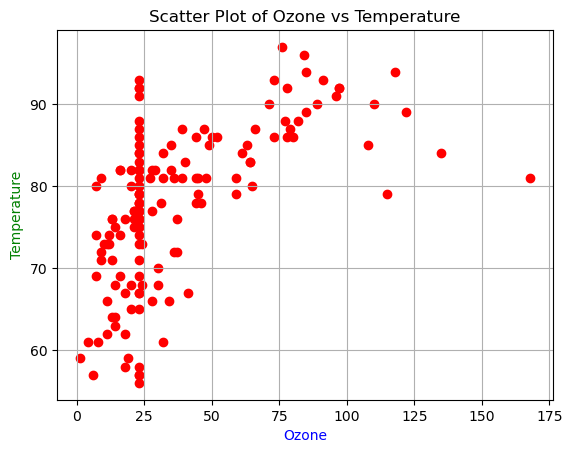

In [70]:
import matplotlib.pyplot as plt

plt.scatter(X, Y, c='red')  # Scatter points in red
plt.xlabel("Ozone", color='blue')  # X-axis label in blue
plt.ylabel("Temperature", color='green')  # Y-axis label in green
plt.title("Scatter Plot of Ozone vs Temperature")  
plt.grid(True)  
plt.show()
